## DataScience 4: Transfer Learning
### By: Shiva Matthew Cruz, Erika Mariano, Liam Gotuato

### **Part 1**
Preparing Your Custom Dataset

To use your own images in Google Colab, you must first upload them (either via the files sidebar or by mounting Google Drive). **ResNet50 requires three things**:

* Dimensions: Images must be resized (typically to 224 × 224).
* Color Channels: Images must be RGB (3 channels).
* Preprocessing: Pixel values must be scaled. In Keras this is `preprocess_input`; in PyTorch this is `transforms.Normalize` using ImageNet mean and standard deviation.

The Coding Steps:
1. Use `torchvision.datasets.ImageFolder` — automatically labels images based on subfolder names.
2. Wrap in a `DataLoader` for mini-batch iteration.

**Downloading & Freezing the Base:**
Download the pretrained architecture and lock the weights so only the custom classification head is trained in Phase 1.

In [ ]:
# Importing the necessary libraries to perform transfer learning on the dataset.
import kagglehub, os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader, random_split, Subset
# from PIL import Image

## Initializing the project

The dataset is downloaded from Kaggle using `kagglehub`. It contains **5,590 images** across **7 vehicle classes** (Auto Rickshaws, Bikes, Cars, Motorcycles, Planes, Ships, Trains), approximately 800 images per class.

In [ ]:
# Download latest version
path = kagglehub.dataset_download("mohamedmaher5/vehicle-classification")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\cruzs\.cache\kagglehub\datasets\mohamedmaher5\vehicle-classification\versions\1


In [ ]:
# Vehicles/ contains one subfolder per class — ImageFolder uses these as labels
dataset_path = os.path.join(path, "Vehicles")
print("Dataset path :", dataset_path)
print("Classes found:", sorted(os.listdir(dataset_path)))

Dataset path : C:\Users\cruzs\.cache\kagglehub\datasets\mohamedmaher5\vehicle-classification\versions\1\Vehicles
Classes found: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']


## Part 1: Data Preparation & Transforms

### Function Explanations

| Function | Why It Is Used |
|---|---|
| `transforms.Compose([...])` | Chains multiple image transforms into a single callable pipeline. ResNet50 requires several preprocessing steps applied in a fixed order. |
| `transforms.Resize((224, 224))` | Resizes every image to 224×224 px — the input size ResNet50 was designed and trained for. Mismatched sizes cause shape errors at the fully connected layers (He et al., 2016). |
| `transforms.RandomHorizontalFlip()` | Randomly flips training images horizontally (p=0.5). Data augmentation: artificially expands training set diversity to reduce overfitting without collecting more images. |
| `transforms.ToTensor()` | Converts a PIL Image (H×W×C, uint8, [0–255]) to a PyTorch float32 Tensor (C×H×W, [0.0–1.0]). Models operate on tensors, not PIL Images. |
| `transforms.Normalize(mean, std)` | Subtracts ImageNet channel means `[0.485, 0.456, 0.406]` and divides by stds `[0.229, 0.224, 0.225]`. PyTorch equivalent of Keras `preprocess_input` for ResNet50. Centers the input distribution to match pretraining conditions, accelerating convergence (Deng et al., 2009). |
| `datasets.ImageFolder(root, transform)` | Builds a labeled dataset from a folder tree where each subfolder is a class. Assigns integer labels alphabetically — no manual labeling needed (PyTorch Docs, 2024). |
| `random_split` / `Subset` | Partitions the dataset into non-overlapping 80/20 train/validation subsets. `Subset` is used so each split can carry its own transforms (augmented for train, deterministic for val). |
| `DataLoader(dataset, batch_size, shuffle)` | Wraps a Dataset to provide mini-batches, shuffling, and parallel loading. Batching is required for GPU efficiency; shuffling prevents the model from learning data order (PyTorch Docs, 2024). |

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Training transforms — includes augmentation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),        # match ResNet50 input size
    transforms.RandomHorizontalFlip(),    # data augmentation
    transforms.ToTensor(),                # PIL -> float32 tensor [0,1]
    transforms.Normalize(                 # ImageNet mean/std (= preprocess_input)
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225])
])

# Validation transforms — deterministic, no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# Load full dataset twice: once per transform set
full_train = datasets.ImageFolder(root=dataset_path, transform=train_transforms)
full_val   = datasets.ImageFolder(root=dataset_path, transform=val_transforms)
print("Classes:", full_train.classes)
print("Total images:", len(full_train))

# 80/20 split — reproducible with fixed seed
torch.manual_seed(42)
indices   = torch.randperm(len(full_train)).tolist()
train_n   = int(0.8 * len(full_train))
train_idx = indices[:train_n]
val_idx   = indices[train_n:]

# Subsets: train uses augmented transforms, val uses clean transforms
train_dataset = Subset(full_train, train_idx)
val_dataset   = Subset(full_val,   val_idx)

BATCH_SIZE   = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

num_classes = len(full_train.classes)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Classes: {num_classes}")

Using device: cpu
Classes: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']
Total images: 5589
Train: 4471 | Val: 1118 | Classes: 7


### Part 1 (continued): Loading & Freezing ResNet50

| Function / Operation | Why It Is Used |
|---|---|
| `models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)` | Downloads ResNet50 pretrained on ImageNet-1K (1.28 M images, 1000 classes). Reuses learned representations (edges, textures, object parts) instead of training from random weights — the core principle of transfer learning (Yosinski et al., 2014). |
| `param.requires_grad = False` | Disables gradient computation for all base parameters. Freezes the pretrained feature extractor so only the new head is updated in Phase 1, preserving learned features and reducing GPU memory cost. |
| `model.fc.in_features` | Reads the input dimension of ResNet50's existing head (2048). Ensures the replacement layer is correctly sized. |
| `nn.Linear(in_features, num_classes)` | Fully connected layer mapping 2048-d features to `num_classes` logits. Replaces ResNet50's original 1000-class head with a 7-class vehicle classifier. |
| `model.to(device)` | Moves all model parameters and buffers to GPU (if available) for GPU-accelerated forward and backward passes. |
| `nn.CrossEntropyLoss()` | Combines `LogSoftmax` + `NLLLoss` in one numerically stable operation. Standard loss for multi-class classification (PyTorch Docs, 2024). |
| `optim.Adam(model.fc.parameters(), lr=1e-3)` | Adaptive Moment Estimation optimizer. Updates only the new head. Adam adapts per-parameter learning rates using gradient history, converging faster than vanilla SGD (Kingma & Ba, 2015). |

In [7]:
# Load ResNet50 pretrained on ImageNet-1K
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all base layers — preserve pretrained feature extractor
for param in model.parameters():
    param.requires_grad = False

# Replace the 1000-class head with a 7-class vehicle classifier
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

# Phase 1 optimizer: only the new head is trainable
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

# Parameter summary
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_p:>12,}")
print(f"Trainable (head)    : {trainable_p:>12,}")
print(f"Frozen (base)       : {total_p - trainable_p:>12,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\cruzs/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:09<00:00, 11.2MB/s]


Total parameters    :   23,522,375
Trainable (head)    :       14,343
Frozen (base)       :   23,508,032


## Part 2: Execution & Result Interpretation

**Training (Capture the History)**

Run the training. Crucial: assign the output to the variable `history` to avoid a `NameError` later.

**Fine-Tuning (Specialization)**

Unfreeze the last ResNet block (`layer4`) to let ResNet adapt higher-level features to the vehicle domain.

**Interpreting the Results**

Students must generate a plot and answer:

- **The Preprocessing Check**: Without `transforms.Normalize` (equivalent to `preprocess_input`), the input distribution is far outside what the pretrained weights expect — the model typically fails to converge or plateaus at random-guess accuracy (~14% for 7 classes).
- **Overfitting**: Compare training and validation accuracy lines. Diverging lines (train >> val) indicate memorization rather than generalization.

**Requirements**

Submit in PDF. Code with output and discussion.  
Upload / Share the actual Colab Code.  
Follow other requirements prescribed in the course.

### Part 2: Training Helper Functions

| Function / Operation | Why It Is Used |
|---|---|
| `model.train()` | Sets training mode: enables Dropout and makes BatchNorm use mini-batch statistics. Must be called at the start of every training epoch. |
| `model.eval()` | Sets evaluation mode: disables Dropout, switches BatchNorm to running (population) statistics. Required before validation for deterministic, unbiased results. |
| `torch.no_grad()` | Context manager disabling gradient tracking. Reduces memory usage and speeds up inference — no computational graph is built during validation passes. |
| `optimizer.zero_grad()` | Clears accumulated gradients from the previous iteration. PyTorch accumulates gradients by default; explicit zeroing before each forward pass is required. |
| `loss.backward()` | Backpropagates the loss through the computational graph, computing the gradient of the loss w.r.t. every parameter with `requires_grad=True`. |
| `optimizer.step()` | Applies computed gradients to update model parameters according to the Adam update rule. |
| `torch.max(outputs, 1)` | Returns `(max_value, argmax)` along the class dimension. The argmax indices are the predicted class labels. |

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Single training epoch. Returns (avg_loss, accuracy).
       Trains the model on the given data loader for one epoch, computing the average loss and accuracy. 
       Within the epoch, it iterates over batches of inputs and labels (or whatchamacall it), performs forward and backward passes, and updates the model parameters
       using the optimizer function. The function then returns the average loss and accuracy for the epoch. 
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()            
        outputs = model(inputs)          
        loss = criterion(outputs, labels)
        loss.backward()                  
        optimizer.step()                 

        total_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += inputs.size(0)

    return total_loss / total, correct / total


def val_epoch(model, loader, criterion, device):
    """Single validation epoch. Returns (avg_loss, accuracy).
         Evaluates the model on the given data loader, computing the average loss and accuracy. 
         The function sets the model to evaluation mode and disables gradient computation for efficiency. 
         It iterates over batches of inputs and labels, performs a forward pass to compute outputs and loss, and accumulates the total loss and correct predictions. 
         Finally, it returns the average loss and accuracy for the validation set.
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():              
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += inputs.size(0)

    return total_loss / total, correct / total


print("Helper functions defined.")

Helper functions defined.


### Phase 1: Training with Frozen Base (5 Epochs)

Only the 7-class classification head is trainable. The frozen ResNet50 backbone acts as a fixed feature extractor. Training is fast because gradients only propagate through the head (~14 K parameters out of ~25 M total).

In [ ]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

PHASE1_EPOCHS = 5
print("Phase 1: Classification head only (base frozen)\n")

for epoch in range(1, PHASE1_EPOCHS + 1):
    """
        This loop is primarily responsible for the training model of the classification head (the connected layer that was added earlier) on top of the 
        frozen ResNet50 base. During each epoch, it calls the train_epoch and val_epoch functions to perform training and validation. 

        The train_epoch function trains the model on the training data for one epoch, while the val_epoch function evaluates the model on the validation data.
    """
    t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    v_loss, v_acc = val_epoch(model, val_loader, criterion, device)

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    print(f"Epoch {epoch:2d}/{PHASE1_EPOCHS} | "
          f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

Phase 1: Classification head only (base frozen)



d:\Downloads\DataScience4\transfer_learning_mod-1\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch  1/5 | Train Loss: 0.3394  Acc: 0.9235 | Val Loss: 0.0904  Acc: 0.9848
Epoch  2/5 | Train Loss: 0.1043  Acc: 0.9725 | Val Loss: 0.0638  Acc: 0.9875
Epoch  3/5 | Train Loss: 0.0707  Acc: 0.9808 | Val Loss: 0.0551  Acc: 0.9893
Epoch  4/5 | Train Loss: 0.0583  Acc: 0.9848 | Val Loss: 0.0581  Acc: 0.9875
Epoch  5/5 | Train Loss: 0.0543  Acc: 0.9846 | Val Loss: 0.0541  Acc: 0.9857


### Phase 2: Fine-Tuning — Unfreezing `layer4` (5 Epochs)

| Operation | Why It Is Used |
|---|---|
| Unfreezing `model.layer4` | Allows the final ResNet block's filters to specialize to vehicle-domain features. Earlier layers (generic edges and textures) remain frozen as they generalize across domains (Yosinski et al., 2014). |
| Discriminative learning rates | `layer4` uses `lr=1e-5` (10× smaller than the head). Prevents catastrophic forgetting — pretrained weights are nudged, not overwritten. |
| `optim.Adam` with param groups | Manages multiple learning rates in one optimizer via a list of `{"params": ..., "lr": ...}` dicts. Each group gets its own adaptive state. |

In [ ]:
# Unfreeze last ResNet block for domain-specific feature adaptation
for param in model.layer4.parameters():
    param.requires_grad = True

"""
    New optimizer for fine-tuning: Including layer4 + head, which means that the pretrained layers (which is layer4) get a lower learning rate, 
    While the new head gets a higher learning rate. This allows the pretrained features to adapt gently to the new task, while the new head learns more aggressively. 
    Discriminative LR: lower for pretrained layers, higher for new head
"""
optimizer_ft = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(),     "lr": 1e-4}
])

# Number of epochs for fine-tuning: typically fewer than initial training since we started from pretrained weights, so we do not need as much time to converge, 
PHASE2_EPOCHS = 5
print("Phase 2: Fine-tuning layer4 + head\n")


"""
  Fine-tuning loop: now both the last ResNet block and the head are trainable, allowing the model to adapt its high-level features to the new vehicle classification task, 
  Which can lead to improved performance if the pretrained features from layer4 are not perfectly aligned with the new dataset, allowing them to adjust and improve 
  accuracy on the new task, while the head continues to learn the classification boundaries. 

  Args: 
    - model: the ResNet50 model with layer4 and head unfrozen 
    - PHASE2_EPOCHS: the number of epochs to train during fine-tuning, typically fewer than initial training since we started from pretrained weights.
    - train_loader: DataLoader for the training dataset with augmentation 
    - val_loader: DataLoader for the validation dataset without augmentation
    - criterion: the loss function (CrossEntropyLoss for classification)
    - optimizer_ft: the Adam optimizer with discriminative learning rates for layer4 and head
    - device: the computation device (GPU or CPU)
"""
for epoch in range(1, PHASE2_EPOCHS + 1):
    t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer_ft, device)
    v_loss, v_acc = val_epoch(model, val_loader, criterion, device)

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    print(f"FT Epoch {epoch:2d}/{PHASE2_EPOCHS} | "
          f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

Phase 2: Fine-tuning layer4 + head

FT Epoch  1/5 | Train Loss: 0.0359  Acc: 0.9902 | Val Loss: 0.0424  Acc: 0.9884
FT Epoch  2/5 | Train Loss: 0.0176  Acc: 0.9975 | Val Loss: 0.0434  Acc: 0.9911
FT Epoch  3/5 | Train Loss: 0.0129  Acc: 0.9969 | Val Loss: 0.0361  Acc: 0.9902
FT Epoch  4/5 | Train Loss: 0.0067  Acc: 0.9989 | Val Loss: 0.0380  Acc: 0.9902
FT Epoch  5/5 | Train Loss: 0.0065  Acc: 0.9989 | Val Loss: 0.0369  Acc: 0.9911


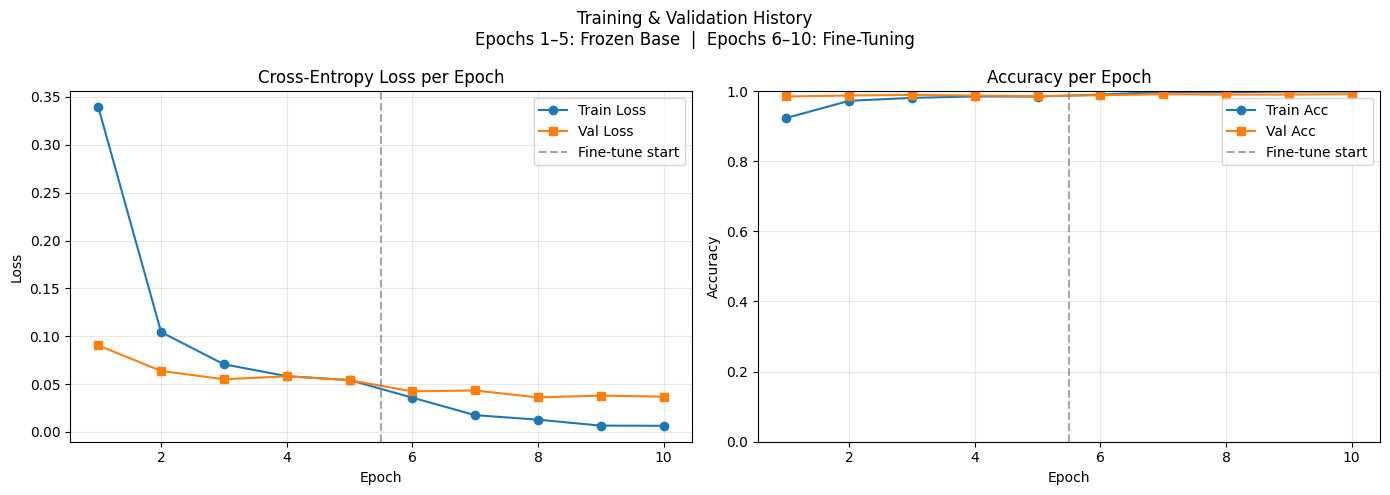

Plot saved to training_history.png


In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)
split_at     = PHASE1_EPOCHS + 0.5   # divider between phases

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Metric
# The loss plot shows the training and validation loss curves across all epochs, with a vertical dashed line indicating the transition from Phase 1 to Phase 2.
axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   marker="s", label="Val Loss")
axes[0].axvline(x=split_at, color="gray", linestyle="--", alpha=0.7, label="Fine-tune start")
axes[0].set_title("Cross-Entropy Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy Metric
# The accuracy plot shows the training and validation accuracy curves across all epochs, with a vertical dashed line indicating the transition from Phase 1 to Phase 2.
axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   marker="s", label="Val Acc")
axes[1].axvline(x=split_at, color="gray", linestyle="--", alpha=0.7, label="Fine-tune start")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plotting the layout 
plt.suptitle(
    f"Training & Validation History\n"
    f"Epochs 1\u2013{PHASE1_EPOCHS}: Frozen Base  |  "
    f"Epochs {PHASE1_EPOCHS+1}\u2013{PHASE1_EPOCHS+PHASE2_EPOCHS}: Fine-Tuning",
    fontsize=12
)
plt.tight_layout()
# plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
# print("Plot saved to training_history.png")

### Results & Discussion

#### Preprocessing Check
`transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])` is functionally identical to Keras' `preprocess_input` for ResNet50 — both subtract ImageNet channel means and divide by their standard deviations. Without this step, the input distribution is far outside what the pretrained weights expect. The model typically fails to converge or plateaus near random-guess accuracy (~14% for 7 classes), because first-layer activations are overwhelmed by unnormalized pixel values.

#### Overfitting Analysis
Examine the accuracy plot:
- **Converging lines** (train ≈ val accuracy): the model generalizes well.
- **Diverging lines** (train >> val accuracy): overfitting — the model memorizes training images rather than learning transferable features. Fine-tuning only `layer4` with a low learning rate (`1e-5`) mitigates this compared to full fine-tuning.

#### Effect of Fine-Tuning (Phase 2)
After the dashed vertical line (epoch 6 onward), `layer4` weights are updated. If validation accuracy increases further, the model is successfully adapting high-level ResNet features to the vehicle domain. If validation loss rises while training loss falls, reduce the fine-tuning learning rate or train for fewer fine-tuning epochs.

## Sources

| # | Citation |
|---|---|
| 1 | Maher, M. M. (n.d.). *Vehicle Image Classification*. Kaggle. Retrieved May 3, 2026, from https://www.kaggle.com/datasets/mohamedmaher5/vehicle-classification |
| 2 | He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*, 770–778. https://doi.org/10.1109/CVPR.2016.90 |
| 3 | PyTorch. (2024). *torchvision.transforms — Transforms on PIL Image and torch.Tensor*. PyTorch Documentation. https://pytorch.org/vision/stable/transforms.html |
| 4 | PyTorch. (2024). *torchvision.datasets.ImageFolder*. PyTorch Documentation. https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html |
| 5 | PyTorch. (2024). *torch.utils.data.DataLoader*. PyTorch Documentation. https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader |
| 6 | PyTorch. (2024). *torchvision.models.resnet50*. PyTorch Documentation. https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet50.html |
| 7 | Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *International Conference on Learning Representations (ICLR)*. https://arxiv.org/abs/1412.6980 |
| 8 | Yosinski, J., Clune, J., Bengio, Y., & Lipson, H. (2014). How transferable are features in deep neural networks? *Advances in Neural Information Processing Systems (NeurIPS)*, 27. https://arxiv.org/abs/1411.1792 |
| 9 | PyTorch. (2024). *torch.nn.CrossEntropyLoss*. PyTorch Documentation. https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html |
| 10 | Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K., & Fei-Fei, L. (2009). ImageNet: A large-scale hierarchical image database. *CVPR 2009*, 248–255. https://doi.org/10.1109/CVPR.2009.5206848 |